In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import warnings

In [2]:
warnings.filterwarnings('ignore') #ignore all warnings

In [3]:
data = pd.read_csv('train.csv')

In [4]:
data.sample(5) #target column is Item_Outlet_Sales

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
1609,FDU59,5.78,Low Fat,0.096386,Breads,163.5552,OUT046,1997,Small,Tier 1,Supermarket Type1,1787.0072
395,FDQ56,6.59,Low Fat,0.105761,Fruits and Vegetables,84.8908,OUT049,1999,Medium,Tier 1,Supermarket Type1,1677.8160
6471,FDB52,17.75,low fat,0.030497,Dairy,256.9672,OUT045,2002,NaN,Tier 2,Supermarket Type1,1534.0032
6268,FDZ59,6.63,reg,0.174111,Baking Goods,166.8500,OUT010,1998,NaN,Tier 3,Grocery Store,499.3500
5216,NCH55,NaN,Low Fat,0.034504,Household,125.2020,OUT027,1985,Medium,Tier 3,Supermarket Type3,2783.0440


Find Dataset's Shape : Total number of rows and columns

In [6]:
data.shape

(8523, 12)

Get information about the dataset

In [8]:
data.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


Check Null value in the dataset

In [10]:
data.isnull().sum()

Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

In [11]:
per = data.isnull().sum() * 100 / len(data)
per

Item_Identifier               0.000000
Item_Weight                  17.165317
Item_Fat_Content              0.000000
Item_Visibility               0.000000
Item_Type                     0.000000
Item_MRP                      0.000000
Outlet_Identifier             0.000000
Outlet_Establishment_Year     0.000000
Outlet_Size                  28.276428
Outlet_Location_Type          0.000000
Outlet_Type                   0.000000
Item_Outlet_Sales             0.000000
dtype: float64

If the missing value is more than 5% then handling it is most important. 

Taking care of Duplicated Values

In [14]:
data.duplicated().any() #True = Duplicated; False = Not Duplicated. 

False

Handling Missing Values

In [16]:
data['Item_Weight']

0        9.300
1        5.920
2       17.500
3       19.200
4        8.930
         ...  
8518     6.865
8519     8.380
8520    10.600
8521     7.210
8522    14.800
Name: Item_Weight, Length: 8523, dtype: float64

Above column has numerical data and missing values can be handelled by a) Univariate Imputation and b) Bivariate Imputation. 
a) Univariate Imputation
- Mean
- Median
- Mode - Frequent Values
- Constant
- Interpolation - with adjacent values

b) Bivariate Imputation
- Regression Imputation
- K-nearest neighbors imputation
- Machine Learning Based Imputation

In [18]:
data['Outlet_Size']

0       Medium
1       Medium
2       Medium
3          NaN
4         High
         ...  
8518      High
8519       NaN
8520     Small
8521    Medium
8522     Small
Name: Outlet_Size, Length: 8523, dtype: object

Univariate Imputation

In [20]:
mean_weight = data['Item_Weight'].mean()
median_weight = data['Item_Weight'].median()
print(mean_weight, median_weight)

12.857645184135976 12.6


In [21]:
data['Item_Weight_mean'] = data['Item_Weight'].fillna(mean_weight)
data['Item_Weight_median'] = data['Item_Weight'].fillna(median_weight)

In [22]:
data.head(1)

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_mean,Item_Weight_median
0,FDA15,9.3,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,9.3


In [23]:
print('Original Weight Variable Variance', data['Item_Weight'].var())
print('Item Weight Variance after mean imputation', data['Item_Weight_mean'].var())
print('Item Weight Variance after median imputation', data['Item_Weight_median'].var())

#Median and Mean reduce variation.

Original Weight Variable Variance 21.56168825983637
Item Weight Variance after mean imputation 17.860121735060453
Item Weight Variance after median imputation 17.869561454073366


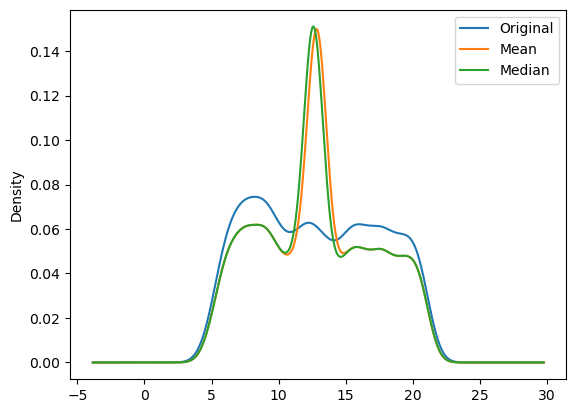

In [24]:
data['Item_Weight'].plot(kind = 'kde', label = 'Original')
data['Item_Weight_mean'].plot(kind = 'kde', label = 'Mean')
data['Item_Weight_median'].plot(kind = 'kde', label = 'Median')

plt.legend()
plt.show()

<Axes: >

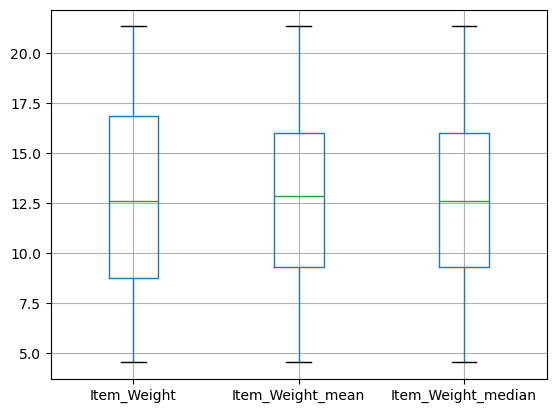

In [25]:
data[['Item_Weight','Item_Weight_mean','Item_Weight_median']].boxplot()

In [26]:
data['Item_Weight_Interpolate'] = data['Item_Weight'].interpolate(method='linear')

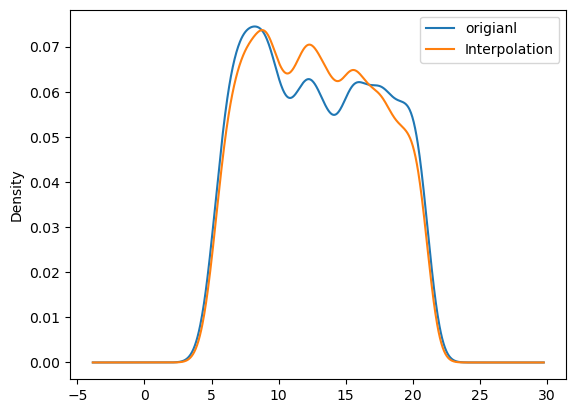

In [27]:
data['Item_Weight'].plot(kind = 'kde', label = 'origianl')
data['Item_Weight_Interpolate'].plot(kind = 'kde', label = 'Interpolation')
plt.legend()
plt.show()

Multivariate Imputation

KNN - It works by finding the “nearest neighbors” (rows) that have similar patterns to the row with missing data

In [30]:
from sklearn.impute import KNNImputer

In [31]:
knn = KNNImputer(n_neighbors=10, weights = 'distance')

In [32]:
data['knn_imputer'] = knn.fit_transform(data[['Item_Weight']]).ravel()

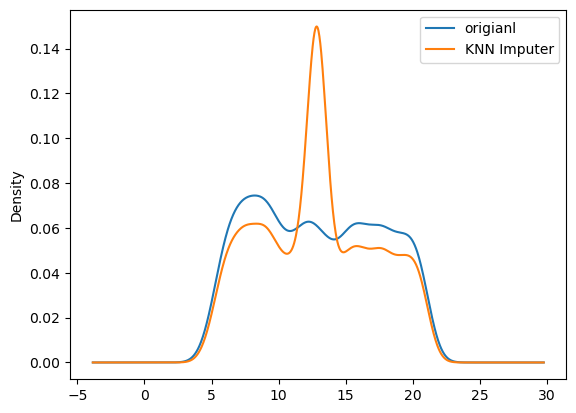

In [33]:
data['Item_Weight'].plot(kind = 'kde', label = 'origianl')
data['knn_imputer'].plot(kind = 'kde', label = 'KNN Imputer')
plt.legend()
plt.show()

After testing above methods we can understand that Interpolation is the best fitted imputation. 

In [35]:
data = data.drop(['Item_Weight','Item_Weight_mean','Item_Weight_median','knn_imputer'], axis = 1)

In [36]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_Interpolate
0,FDA15,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3


In [64]:
data.isnull().sum()

Item_Identifier                 0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
Item_Weight_Interpolate         0
dtype: int64

Outlet_Size

In [67]:
data['Outlet_Size'].value_counts()

Outlet_Size
Medium    2793
Small     2388
High       932
Name: count, dtype: int64

In [69]:
data['Outlet_Type'].value_counts()


Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64

In [75]:
mode_outlet = data.pivot_table(values = 'Outlet_Size', columns = 'Outlet_Type',aggfunc=(lambda x:x.mode()[0])) #Frequent Values

In [77]:
mode_outlet

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [79]:
missing_values = data['Outlet_Size'].isnull()

In [81]:
missing_values

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool

In [87]:
data.loc[missing_values, 'Outlet_Size'] = data.loc[missing_values, 'Outlet_Type'].apply(lambda x :mode_outlet[x])

In [89]:
missing_values

0       False
1       False
2       False
3        True
4       False
        ...  
8518    False
8519     True
8520    False
8521    False
8522    False
Name: Outlet_Size, Length: 8523, dtype: bool

In [91]:
data.isnull().sum()

Item_Identifier              0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
Item_Weight_Interpolate      0
dtype: int64

Item_Fat_Content

In [96]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Visibility', 'Item_Type',
       'Item_MRP', 'Outlet_Identifier', 'Outlet_Establishment_Year',
       'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type',
       'Item_Outlet_Sales', 'Item_Weight_Interpolate'],
      dtype='object')

In [98]:
data['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64

In [100]:
data.replace({'Item_Fat_Content':{'Low Fat':'LF','low fat':'LF','reg':'Regular'}}, inplace = True)

In [102]:
data['Item_Fat_Content'].value_counts()

Item_Fat_Content
LF         5517
Regular    3006
Name: count, dtype: int64

Item_Visibility

In [105]:
data['Item_Visibility']

0       0.016047
1       0.019278
2       0.016760
3       0.000000
4       0.000000
          ...   
8518    0.056783
8519    0.046982
8520    0.035186
8521    0.145221
8522    0.044878
Name: Item_Visibility, Length: 8523, dtype: float64

In [107]:
data['Item_Visibility'].value_counts()

Item_Visibility
0.000000    526
0.076975      3
0.162462      2
0.076841      2
0.073562      2
           ... 
0.013957      1
0.110460      1
0.124646      1
0.054142      1
0.044878      1
Name: count, Length: 7880, dtype: int64

In [109]:
data['Item_Visibility_interpolate'] = data['Item_Visibility'].replace(0, np.nan).interpolate(method = 'linear')

In [111]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_Interpolate,Item_Visibility_interpolate
0,FDA15,LF,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047


In [113]:
data['Item_Visibility_interpolate'].value_counts()

Item_Visibility_interpolate
0.076975    3
0.044024    2
0.040912    2
0.076856    2
0.078759    2
           ..
0.021011    1
0.099189    1
0.076866    1
0.014116    1
0.044878    1
Name: count, Length: 8405, dtype: int64

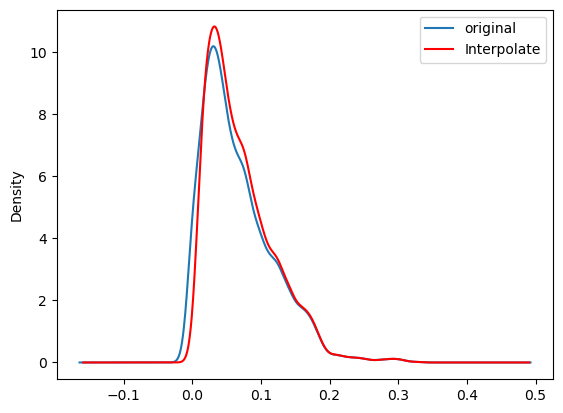

In [115]:
data['Item_Visibility'].plot(kind = 'kde', label = 'original')
data['Item_Visibility_interpolate'].plot(kind = 'kde', color = 'red', label = 'Interpolate')
plt.legend()
plt.show()

In [117]:
data = data.drop('Item_Visibility', axis = 1)

In [119]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_Interpolate,Item_Visibility_interpolate
0,FDA15,LF,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047


Item_Type

In [121]:
data.columns

Index(['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Item_MRP',
       'Outlet_Identifier', 'Outlet_Establishment_Year', 'Outlet_Size',
       'Outlet_Location_Type', 'Outlet_Type', 'Item_Outlet_Sales',
       'Item_Weight_Interpolate', 'Item_Visibility_interpolate'],
      dtype='object')

In [125]:
data['Item_Type'].value_counts()

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

Item_Identifier

In [148]:
data['Item_Identifier'].value_counts()

Item_Identifier
FD    6125
NC    1599
DR     799
Name: count, dtype: int64

In [150]:
data['Item_Identifier'] = data['Item_Identifier'].apply(lambda x : x[:2])

In [152]:
data['Item_Identifier'].value_counts()

Item_Identifier
FD    6125
NC    1599
DR     799
Name: count, dtype: int64

Outlet_Establishment_Year

In [156]:
import datetime as dt

In [158]:
current_year = dt.datetime.today().year

In [160]:
current_year

2025

In [162]:
current_year - data['Outlet_Establishment_Year']

0       26
1       16
2       26
3       27
4       38
        ..
8518    38
8519    23
8520    21
8521    16
8522    28
Name: Outlet_Establishment_Year, Length: 8523, dtype: int64

In [164]:
data['Outlet_age'] = current_year - data['Outlet_Establishment_Year']

In [170]:
data.head(1)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_Interpolate,Item_Visibility_interpolate,Outlet_age
0,FD,LF,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.138,9.3,0.016047,26


In [172]:
data = data.drop('Outlet_Establishment_Year', axis = 1)

In [174]:
data.head()

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_Interpolate,Item_Visibility_interpolate,Outlet_age
0,FD,LF,Dairy,249.8092,OUT049,Medium,Tier 1,Supermarket Type1,3735.1380,9.30,0.016047,26
1,DR,Regular,Soft Drinks,48.2692,OUT018,Medium,Tier 3,Supermarket Type2,443.4228,5.92,0.019278,16
2,FD,LF,Meat,141.6180,OUT049,Medium,Tier 1,Supermarket Type1,2097.2700,17.50,0.016760,26
3,FD,Regular,Fruits and Vegetables,182.0950,OUT010,Small,Tier 3,Grocery Store,732.3800,19.20,0.015755,27
4,NC,LF,Household,53.8614,OUT013,High,Tier 3,Supermarket Type1,994.7052,8.93,0.014751,38


Handling Categorical Columns 

LabelIncode is used for dependent variable according to SKLEARN 

In [179]:
from sklearn.preprocessing import OrdinalEncoder

data_encoded = data.copy()
cat_cols = data.select_dtypes(include = ['object']).columns

for col in cat_cols:
    oe = OrdinalEncoder()
    data_encoded[col] = oe.fit_transform(data_encoded[[col]])
    print(oe.categories_)

[array(['DR', 'FD', 'NC'], dtype=object)]
[array(['LF', 'Regular'], dtype=object)]
[array(['Baking Goods', 'Breads', 'Breakfast', 'Canned', 'Dairy',
       'Frozen Foods', 'Fruits and Vegetables', 'Hard Drinks',
       'Health and Hygiene', 'Household', 'Meat', 'Others', 'Seafood',
       'Snack Foods', 'Soft Drinks', 'Starchy Foods'], dtype=object)]
[array(['OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027',
       'OUT035', 'OUT045', 'OUT046', 'OUT049'], dtype=object)]
[array(['High', 'Medium', 'Small'], dtype=object)]
[array(['Tier 1', 'Tier 2', 'Tier 3'], dtype=object)]
[array(['Grocery Store', 'Supermarket Type1', 'Supermarket Type2',
       'Supermarket Type3'], dtype=object)]


In [181]:
data_encoded.head(3)

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,Item_Weight_Interpolate,Item_Visibility_interpolate,Outlet_age
0,1.0,0.0,4.0,249.8092,9.0,1.0,0.0,1.0,3735.1380,9.30,0.016047,26
1,0.0,1.0,14.0,48.2692,3.0,1.0,2.0,2.0,443.4228,5.92,0.019278,16
2,1.0,0.0,10.0,141.6180,9.0,1.0,0.0,1.0,2097.2700,17.50,0.016760,26


In [183]:
X = data_encoded.drop('Item_Outlet_Sales', axis = 1)
y = data_encoded['Item_Outlet_Sales']

In [191]:
y #dependent Var

0       3735.1380
1        443.4228
2       2097.2700
3        732.3800
4        994.7052
          ...    
8518    2778.3834
8519     549.2850
8520    1193.1136
8521    1845.5976
8522     765.6700
Name: Item_Outlet_Sales, Length: 8523, dtype: float64

In [193]:
X #independent Var

,Item_Identifier,Item_Fat_Content,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Weight_Interpolate,Item_Visibility_interpolate,Outlet_age
0,1.0,0.0,4.0,249.8092,9.0,1.0,0.0,1.0,9.300,0.016047,26
1,0.0,1.0,14.0,48.2692,3.0,1.0,2.0,2.0,5.920,0.019278,16
2,1.0,0.0,10.0,141.6180,9.0,1.0,0.0,1.0,17.500,0.016760,26
3,1.0,1.0,6.0,182.0950,0.0,2.0,2.0,0.0,19.200,0.015755,27
4,2.0,0.0,9.0,53.8614,1.0,0.0,2.0,1.0,8.930,0.014751,38
...,...,...,...,...,...,...,...,...,...,...,...
8518,1.0,0.0,13.0,214.5218,1.0,0.0,2.0,1.0,6.865,0.056783,38
8519,1.0,1.0,0.0,108.1570,7.0,2.0,1.0,1.0,8.380,0.046982,23
8520,2.0,0.0,8.0,85.1224,6.0,2.0,1.0,1.0,10.600,0.035186,21
8521,1.0,1.0,13.0,103.1332,3.0,1.0,2.0,2.0,7.210,0.145221,16


Random Forest Regressor

In [204]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
#r^2 score
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(rf, X, y, cv = 5, scoring = 'r2')
print(scores.mean())

0.5549992903957147


XGBRFRegressor

In [210]:
!pip install xgboost


   ---------------------------------------- 0.0/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.3/150.0 MB ? eta -:--:--
   ---------------------------------------- 0.8/150.0 MB 2.6 MB/s eta 0:00:59
   ---------------------------------------- 1.6/150.0 MB 2.9 MB/s eta 0:00:52
    --------------------------------------- 2.4/150.0 MB 3.3 MB/s eta 0:00:46
    --------------------------------------- 3.4/150.0 MB 3.5 MB/s eta 0:00:43
   - -------------------------------------- 4.7/150.0 MB 3.9 MB/s eta 0:00:38
   - -------------------------------------- 6.0/150.0 MB 4.4 MB/s eta 0:00:33
   -- ------------------------------------- 8.7/150.0 MB 5.4 MB/s eta 0:00:27
   --- ------------------------------------ 11.3/150.0 MB 6.2 MB/s eta 0:00:23
   --- ------------------------------------ 14.2/150.0 MB 7.1 MB/s eta 0:00:20
   ---- ----------------------------------- 18.4/150.0 MB 8.4 MB/s eta 0:00:16
   ----- ---------------------------------- 22.0/150.0 MB 9.2 MB/s eta 0:00

In [214]:
from xgboost import XGBRFRegressor
xg = XGBRFRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(xg, X, y, cv = 5, scoring = 'r2')
print(scores.mean())

0.5954460635154428


In [216]:
xg = XGBRFRegressor(n_estimators = 100, random_state = 42)

xg1 = xg.fit(X,y)
pd.DataFrame({
    'feature':X.columns,
    'XGBRF_importance':xg1.feature_importances_
}).sort_values(by = 'XGBRF_importance', ascending = False)

,feature,XGBRF_importance
7,Outlet_Type,0.421562
10,Outlet_age,0.180672
3,Item_MRP,0.151871
5,Outlet_Size,0.141116
4,Outlet_Identifier,0.091748
6,Outlet_Location_Type,0.003652
9,Item_Visibility_interpolate,0.003080
8,Item_Weight_Interpolate,0.002277
2,Item_Type,0.002099
0,Item_Identifier,0.001001


In [218]:
['Outlet_Location_Type', 'Item_Visibility_interpolate', 'Item_Weight_Interpolate', 'Item_Type', 'Item_Identifier', 'Item_Fat_Content']


['Outlet_Location_Type',
 'Item_Visibility_interpolate',
 'Item_Weight_Interpolate',
 'Item_Type',
 'Item_Identifier',
 'Item_Fat_Content']

In [224]:
from xgboost import XGBRFRegressor
xg = XGBRFRegressor(n_estimators=100, random_state=42)
scores = cross_val_score(xg1, X.drop(['Outlet_Location_Type', 'Item_Visibility_interpolate', 'Item_Weight_Interpolate', 'Item_Type', 'Item_Identifier', 'Item_Fat_Content']
,axis = 1), y, cv = 5, scoring = 'r2')
print(scores.mean())

0.5962281207882374


In [226]:
final_data = X.drop(columns=['Outlet_Location_Type', 'Item_Visibility_interpolate', 'Item_Weight_Interpolate', 'Item_Type', 'Item_Identifier', 'Item_Fat_Content']
, axis = 1)

In [228]:
final_data

,Item_MRP,Outlet_Identifier,Outlet_Size,Outlet_Type,Outlet_age
0,249.8092,9.0,1.0,1.0,26
1,48.2692,3.0,1.0,2.0,16
2,141.6180,9.0,1.0,1.0,26
3,182.0950,0.0,2.0,0.0,27
4,53.8614,1.0,0.0,1.0,38
...,...,...,...,...,...
8518,214.5218,1.0,0.0,1.0,38
8519,108.1570,7.0,2.0,1.0,23
8520,85.1224,6.0,2.0,1.0,21
8521,103.1332,3.0,1.0,2.0,16


BEST MODEL

In [233]:
from xgboost import XGBRFRegressor

In [239]:
xg_final = XGBRFRegressor()

In [241]:
xg_final.fit(final_data, y)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [243]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

In [245]:
X_train, X_test, y_train, y_test = train_test_split(final_data, y, test_size=0.20, random_state=42)

In [247]:
xg_final.fit(X_train, y_train)

XGBRFRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bytree=None, device=None,
               early_stopping_rounds=None, enable_categorical=False,
               eval_metric=None, feature_types=None, feature_weights=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=None, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=None, n_jobs=None,
               num_parallel_tree=None, objective='reg:squarederror',
               random_state=None, ...)

In [249]:
y_pred = xg_final.predict(X_test)

In [251]:
mean_absolute_error(y_test, y_pred)

713.9045726075293

Prediction on Unseen Data

In [254]:
pred = xg_final.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2057.2124


In [256]:
print(f"Sales Value is between {pred-714.42} and {pred+714.42}")


Sales Value is between 1342.79240234375 and 2771.63240234375


Save Model Using Joblib 

In [259]:
import joblib


In [261]:
joblib.dump(xg_final,'bigmart_model')


['bigmart_model']

In [263]:
model = joblib.load('bigmart_model')


In [265]:
pred = model.predict(np.array([[141.6180,9.0,1.0,1.0,24]]))[0]
print(pred)

2057.2124


In [267]:
print(f"Sales Value is between {pred-714.42} and {pred+714.42}")


Sales Value is between 1342.79240234375 and 2771.63240234375


GUI

In [ ]:
import numpy as np
import datetime as dt
from tkinter import *
import joblib

current_year = dt.datetime.today().year

def show_entry_fields():
    try:
        p1 = float(e1.get())

        text = clicked.get()
        outlet_map = {
            "OUT010": 0, "OUT013": 1, "OUT017": 2, "OUT018": 3, "OUT019": 4,
            "OUT027": 5, "OUT035": 6, "OUT045": 7, "OUT046": 8, "OUT049": 9
        }
        p2 = outlet_map.get(text, 0)

        size_map = {"High": 0, "Medium": 1, "Small": 2}
        p3 = size_map.get(clicked0.get(), 0)

        type_map = {
            "Grocery Store": 0,
            "Supermarket Type1": 1,
            "Supermarket Type2": 2,
            "Supermarket Type3": 3
        }
        p4 = type_map.get(clicked1.get(), 0)

        p5 = current_year - int(e5.get())

        model = joblib.load('bigmart_model')
        result = model.predict(np.array([[p1, p2, p3, p4, p5]]))

        lower = float(result) - 714.42
        upper = float(result) + 714.42

        result_label.config(
            text=f"Estimated Sales Amount: Between {lower:.2f} and {upper:.2f}"
        )
    except Exception as e:
        result_label.config(text=f"Error: {str(e)}")

# GUI Setup
master = Tk()
master.title("Big Mart Sales Prediction")
master.configure(bg="#f2f2f2")
master.geometry("420x400")

title = Label(master, text="Big Mart Sales Prediction using ML", bg="black", fg="white", font=("Arial", 14, "bold"))
title.pack(fill=X, pady=10)

frame = Frame(master, bg="#f2f2f2")
frame.pack(pady=10)

# Variables for OptionMenus
clicked = StringVar(value="OUT010")
clicked0 = StringVar(value="Medium")
clicked1 = StringVar(value="Supermarket Type1")

# Widgets
e1 = Entry(frame)
e2 = OptionMenu(frame, clicked, 'OUT010', 'OUT013', 'OUT017', 'OUT018', 'OUT019', 'OUT027', 'OUT035', 'OUT045', 'OUT046', 'OUT049')
e3 = OptionMenu(frame, clicked0, 'High', 'Medium', 'Small')
e4 = OptionMenu(frame, clicked1, 'Grocery Store', 'Supermarket Type1', 'Supermarket Type2', 'Supermarket Type3')
e5 = Entry(frame)

# Labels and layout
labels = ["Item MRP", "Outlet Identifier", "Outlet Size", "Outlet Type", "Outlet Establishment Year"]
widgets = [e1, e2, e3, e4, e5]

for i, (label_text, widget) in enumerate(zip(labels, widgets)):
    Label(frame, text=label_text, font=("Arial", 10), bg="#f2f2f2").grid(row=i, column=0, padx=10, pady=8, sticky=W)
    widget.grid(row=i, column=1, padx=10, pady=8)

# Predict button
Button(master, text='Predict', command=show_entry_fields, bg="#4CAF50", fg="white", font=("Arial", 10, "bold")).pack(pady=15)

# Result label
result_label = Label(master, text="", font=("Arial", 12), bg="#f2f2f2", fg="blue")
result_label.pack()

mainloop()
